In [2]:
import keras
import ml_edu.experiment
import ml_edu.results
import numpy as np
import pandas as pd
import plotly.express as px

pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.1f}".format

In [3]:
rice_dataset_raw = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/Rice_Cammeo_Osmancik.csv")
rice_dataset_raw

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.6,229.7,85.1,0.9,15617,0.6,Cammeo
1,14656,494.3,206.0,91.7,0.9,15072,0.6,Cammeo
2,14634,501.1,214.1,87.8,0.9,14954,0.7,Cammeo
3,13176,458.3,193.3,87.4,0.9,13368,0.6,Cammeo
4,14688,507.2,211.7,89.3,0.9,15262,0.6,Cammeo
...,...,...,...,...,...,...,...,...
3805,11441,415.9,170.5,85.8,0.9,11628,0.7,Osmancik
3806,11625,421.4,167.7,89.5,0.8,11904,0.7,Osmancik
3807,12437,442.5,183.6,86.8,0.9,12645,0.6,Osmancik
3808,9882,392.3,161.2,78.2,0.9,10097,0.7,Osmancik


In [4]:
rice_dataset = rice_dataset_raw[[
    'Area',
    'Perimeter',
    'Major_Axis_Length',
    'Minor_Axis_Length',
    'Eccentricity',
    'Convex_Area',
    'Extent',
    'Class',
]]

rice_dataset.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.0,3810.0,3810.0,3810.0,3810.0,3810.0,3810.0
mean,12667.7,454.2,188.8,86.3,0.9,12952.5,0.7
std,1732.4,35.6,17.4,5.7,0.0,1777.0,0.1
min,7551.0,359.1,145.3,59.5,0.8,7723.0,0.5
25%,11370.5,426.1,174.4,82.7,0.9,11626.2,0.6
50%,12421.5,448.9,185.8,86.4,0.9,12706.5,0.6
75%,13950.0,483.7,203.6,90.1,0.9,14284.0,0.7
max,18913.0,548.4,239.0,107.5,0.9,19099.0,0.9


In [5]:
min_length = rice_dataset.Major_Axis_Length.min()
print(f"The min for the Major Axis Length in pixel: {min_length:.1f}px")

max_length = rice_dataset.Major_Axis_Length.max()
print(f"The max for the Major Axis Length in pixel: {max_length:.1f}px")

area_range = rice_dataset.Area.max() - rice_dataset.Area.min()
print(f"The range of areas between the smallest and largest rice grains is: {area_range:.1f}")

max_perimeter = rice_dataset.Perimeter.max()
mean_perimeter = rice_dataset.Perimeter.mean()
std_perimeter = rice_dataset.Perimeter.std()
z_score = (max_perimeter - mean_perimeter) / std_perimeter
print(f"The largest perimeter is {z_score:.2f} standard deviations from the mean.")

The min for the Major Axis Length in pixel: 145.3px
The max for the Major Axis Length in pixel: 239.0px
The range of areas between the smallest and largest rice grains is: 11362.0
The largest perimeter is 2.65 standard deviations from the mean.


In [6]:
for x_axis_data, y_axis_data in [
    ('Area', 'Eccentricity'),
    ('Convex_Area', 'Perimeter'),
    ('Major_Axis_Length', 'Minor_Axis_Length'),
    ('Perimeter', 'Extent'),
    ('Eccentricity', 'Major_Axis_Length'),
]:
    px.scatter(rice_dataset, x=x_axis_data, y=y_axis_data, color='Class').show()

In [7]:
x_axis_data='Eccentricity'
y_axis_data='Area'
z_axis_data='Major_Axis_Length'

px.scatter_3d(
    rice_dataset,
    x=x_axis_data,
    y=y_axis_data,
    z=z_axis_data,
    color='Class',
).show()

In [8]:
# Normalize data
feature_mean = rice_dataset.mean(numeric_only=True)
feature_std = rice_dataset.std(numeric_only=True)
numerical_feature = rice_dataset.select_dtypes('number').columns
normalized_dataset = (
    rice_dataset[numerical_feature] - feature_mean
) / feature_std

# Copy the class to the new dataframe
normalized_dataset['Class'] = rice_dataset['Class']

# Examine some of the values of the normalize training set. Notice that most 
# Z-score fall between -1 and +2
normalized_dataset.head()


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,1.5,2.0,2.3,-0.2,2.0,1.5,-1.2,Cammeo
1,1.1,1.1,1.0,0.9,0.4,1.2,-0.6,Cammeo
2,1.1,1.3,1.5,0.3,1.2,1.1,0.4,Cammeo
3,0.3,0.1,0.3,0.2,0.2,0.2,-0.3,Cammeo
4,1.2,1.5,1.3,0.5,1.0,1.3,-0.2,Cammeo


In [9]:
keras.utils.set_random_seed(42)

In [10]:
# Label and split data
# Create a column setting the Cammeo label to '1' and Osmancik label to '0'
# the show 10 randomly selected rows.
normalized_dataset['Class_Bool'] = (
    # Return true if class is Cammeo, and false if the class is Osmancik
    normalized_dataset['Class'] == 'Cammeo'
).astype(int)
normalized_dataset.sample(10)

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_Bool
1011,-0.1,0.1,-0.1,0.2,-0.1,-0.0,-1.0,Cammeo,1
3185,-0.1,-0.5,-0.5,0.4,-0.8,-0.2,-0.3,Osmancik,0
3698,0.1,-0.1,-0.4,0.9,-1.1,0.1,-0.2,Osmancik,0
897,0.2,0.5,0.8,-0.5,1.2,0.2,1.5,Cammeo,1
3245,-1.3,-1.3,-0.9,-1.6,0.5,-1.4,-1.1,Osmancik,0
478,0.2,0.2,0.4,-0.0,0.5,0.2,1.7,Cammeo,1
1731,-0.4,-0.8,-0.8,0.3,-1.0,-0.5,-0.4,Osmancik,0
1025,0.6,0.7,0.6,0.3,0.5,0.6,-0.5,Cammeo,1
429,1.2,1.2,1.4,0.6,1.0,1.2,1.8,Cammeo,1
1330,-0.4,-0.0,0.4,-1.3,1.4,-0.5,-0.1,Cammeo,1


In [11]:
# Create indeces at the 80th and 90th percentiles
number_samples = len(normalized_dataset)
index_80th = round(number_samples * 0.8)
index_90th = index_80th + round(number_samples * 0.1)

# Randomize order and split into train, validation and test with a .8, .1, .1 split
shuffled_dataset = normalized_dataset.sample(frac=1, random_state=100)
train_data = shuffled_dataset.iloc[0:index_80th]
validation_data = shuffled_dataset.iloc[index_80th:index_90th]
test_data = shuffled_dataset.iloc[index_90th:]

# Show the first five rows of the last split
test_data.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_Bool
2405,-0.4,-0.7,-0.8,0.3,-1.1,-0.4,0.3,Osmancik,0
3062,-0.2,-0.0,0.2,-0.7,0.8,-0.2,1.6,Osmancik,0
1155,1.4,1.2,1.1,1.2,0.3,1.3,0.7,Cammeo,1
660,1.2,1.0,0.8,1.3,-0.0,1.2,-0.6,Cammeo,1
2451,-1.2,-1.2,-1.4,-0.3,-1.5,-1.1,0.1,Osmancik,0


In [12]:
label_columns = ['Class', 'Class_Bool']

train_features = train_data.drop(columns=label_columns)
train_labels = train_data['Class_Bool'].to_numpy()
validation_features = validation_data.drop(columns=label_columns)
validation_labels = validation_data['Class_Bool'].to_numpy()
test_features = test_data.drop(columns=label_columns)
test_labels = test_data['Class_Bool'].to_numpy()

In [13]:
# Train the model
# Train the model with Eccentricity, Mojor_Axis_Length and Area
input_fetures = [
    'Eccentricity',
    'Major_Axis_Length',
    'Area',
]

In [14]:
def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric]
) -> keras.Model:
    """Create and compile a simple classification model."""
    model_inputs = [
            keras.Input(name=feature, shape=(1,))
            for feature in settings.input_features
    ]
    # Use a Concatenate layer to assemble the different inputs into a single
    # tensor which will be given as input to the Dense layer.
    # For example: [input_a[0][0], input_2[0][0]]
    
    concatenate_inputs = keras.layers.Concatenate()(model_inputs)
    model_outputs = keras.layers.Dense(
        units=1, name='dense_layer', activation=keras.activations.sigmoid
    )(concatenate_inputs)
    model = keras.Model(inputs=model_inputs, outputs=model_outputs)
    # Call the compile method to transform the layers into a model that
    # keras can execute. Notice that we're using a different lass
    # function for classification than fot regression
    model.compile(
        optimizer=keras.optimizers.RMSprop(
                    settings.learning_rate
                ),
                loss=keras.losses.BinaryCrossentropy(),
                metrics=metrics,
    )
    return model

def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    labels: np.ndarray,
    settings: ml_edu.experiment.ExperimentSettings,
) -> ml_edu.experiment.Experiment:
    """Feed a dataset into the model in order to train it."""
    # The x parameter of keras.model.fit can be a list of array, where
    # each array contains the data for one feature.
    features = {
        feature_name: np.array(dataset[feature_name])
        for feature_name in settings.input_features
    }
    
    history = model.fit(
        x=features,
        y=labels,
        batch_size=settings.batch_size,
        epochs=settings.number_epochs,
    )
    
    return ml_edu.experiment.Experiment(
        name=experiment_name,
        settings=settings,
        model=model,
        epochs=history.epoch,
        metrics_history=pd.DataFrame(history.history)
    )
    
    print("Defined the create_model and train_model functions")
    
    
    

Epoch 1/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.6879 - auc: 0.8524 - loss: 0.5124 - precision: 0.5897 - recall: 0.9565
Epoch 2/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7115 - auc: 0.8697 - loss: 0.4899 - precision: 0.6103 - recall: 0.9537
Epoch 3/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7330 - auc: 0.8822 - loss: 0.4712 - precision: 0.6293 - recall: 0.9575
Epoch 4/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7512 - auc: 0.8931 - loss: 0.4537 - precision: 0.6473 - recall: 0.9551
Epoch 5/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7643 - auc: 0.9022 - loss: 0.4373 - precision: 0.6606 - recall: 0.9553
Epoch 6/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7727 - auc: 0.9105 - loss: 0.4220 - precision: 0.6698 - recall: 0.9533
Epoch 7/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7829 - auc: 0.9176 - loss: 0.4076 - precision: 0.6812 - recall: 0.9521
Epoch 8/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/s

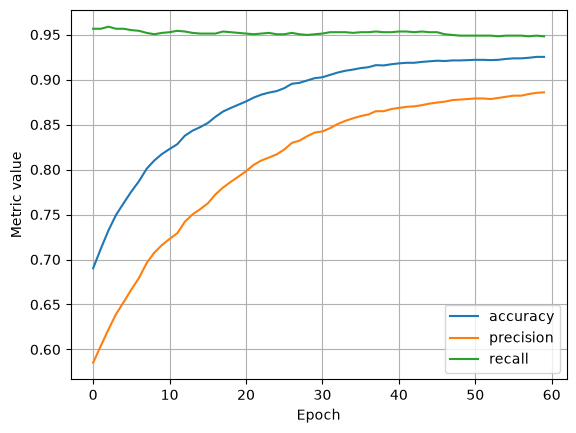

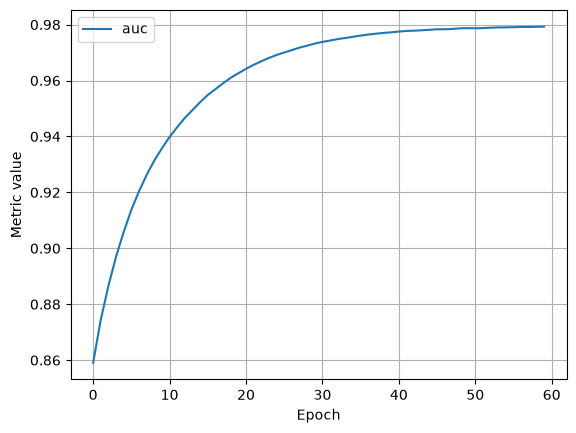

In [ ]:
# Experiment settings 1
settings = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=60,
    batch_size=100,
    classification_threshold=0.35,
    input_features=input_fetures,
)

metrics = [
    keras.metrics.BinaryAccuracy(
        name='accuracy', 
        threshold=settings.classification_threshold
    ),
    keras.metrics.Precision(
        name='precision', 
        thresholds=settings.classification_threshold
    ),
    keras.metrics.Recall(
        name='recall', 
        thresholds=settings.classification_threshold
    ),
    keras.metrics.AUC(num_thresholds=100, name='auc')
]

# Establish the model's topography
model = create_model(settings, metrics)

# Train the model on the training set.
experiment = train_model(
    'baseline', model, train_features, train_labels, settings
)

# Plot metrics vs. epochs
ml_edu.results.plot_experiment_metrics(experiment, ['accuracy', 'precision', 'recall'])
ml_edu.results.plot_experiment_metrics(experiment, ['auc'])





In [19]:
# Evaluate the model against the validation set
def compare_train_validation(experiment: ml_edu.experiment.Experiment, validation_metrics: dict[str, float]):
    print("Comparing metrics between train and validation:")
    for metric, validation_value in validation_metrics.items():
        print("_ _ _ _ _")
        print(f"Train {metric}: {experiment.get_final_metric_value(metric):.4f}")
        print(f"Validation {metric}: {validation_value:.4f}")
        
# Evaluate validation metrics
validation_metrics = experiment.evaluate(validation_features, validation_labels)
compare_train_validation(experiment, validation_metrics)

Comparing metrics between train and validation:
_ _ _ _ _
Train accuracy: 0.9252
Validation accuracy: 0.8950
_ _ _ _ _
Train auc: 0.9793
Validation auc: 0.9722
_ _ _ _ _
Train loss: 0.1844
Validation loss: 0.2155
_ _ _ _ _
Train precision: 0.8858
Validation precision: 0.8449
_ _ _ _ _
Train recall: 0.9481
Validation recall: 0.9349


In [20]:
all_input_features = [
    'Eccentricity',
    'Major_Axis_Length',
    'Minor_Axis_Length',
    'Area',
    'Convex_Area',
    'Perimeter',
    'Extent',
]

Epoch 1/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8803 - auc: 0.9524 - loss: 0.4140 - precision: 0.8317 - recall: 0.9142
Epoch 2/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8918 - auc: 0.9608 - loss: 0.3802 - precision: 0.8485 - recall: 0.9197 
Epoch 3/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8967 - auc: 0.9652 - loss: 0.3545 - precision: 0.8597 - recall: 0.9165
Epoch 4/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9000 - auc: 0.9680 - loss: 0.3323 - precision: 0.8654 - recall: 0.9170
Epoch 5/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9067 - auc: 0.9700 - loss: 0.3131 - precision: 0.8767 - recall: 0.9179
Epoch 6/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9116 - auc: 0.9713 - loss: 0.2964 - precision: 0.8848 - recall: 0.9198
Epoch 7/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9125 - auc: 0.9723 - loss: 0.2819 - precision: 0.8859 - recall: 0.9205
Epoch 8/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/st

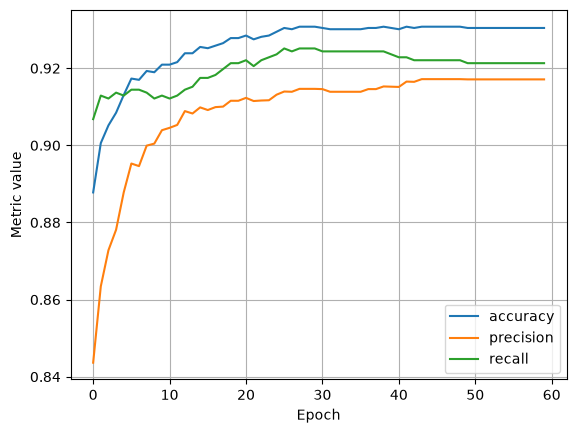

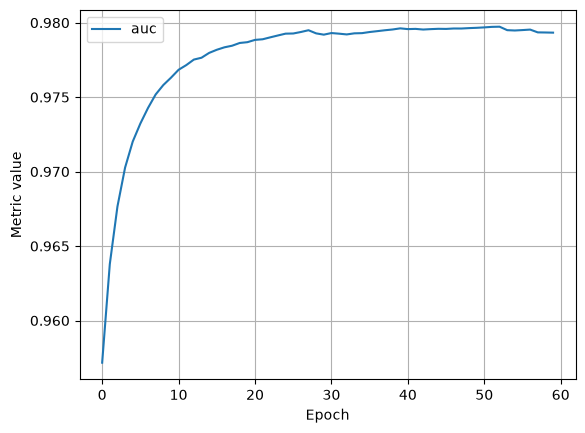

In [21]:
settings_all_features = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=60,
    batch_size=100,
    classification_threshold=0.5,
    input_features=all_input_features,
)

metrics = [
    keras.metrics.BinaryAccuracy(
        name='accuracy',
        threshold=settings_all_features.classification_threshold,
    ),
    keras.metrics.Precision(
        name='precision',
        thresholds=settings_all_features.classification_threshold,
    ),
    keras.metrics.Recall(
        name='recall',
        thresholds=settings_all_features.classification_threshold,
    ),
    keras.metrics.AUC(num_thresholds=100, name='auc')
]

# Model topography
model_all_features = create_model(settings_all_features, metrics)

# Train the model on the training set
experiment_all_feature = train_model(
    'all_features',
    model_all_features,
    train_features,
    train_labels,
    settings_all_features,
)

# Plot metrics vs. epochs
ml_edu.results.plot_experiment_metrics(
    experiment_all_feature, ['accuracy', 'precision', 'recall']
)
ml_edu.results.plot_experiment_metrics(experiment_all_feature, ['auc'])

In [22]:
# Evaluate full-featured model on validation split
validation_metrics_all_features = experiment_all_feature.evaluate(
    validation_features,
    validation_labels,
)
compare_train_validation(experiment_all_feature, validation_metrics_all_features)

Comparing metrics between train and validation:
_ _ _ _ _
Train accuracy: 0.9304
Validation accuracy: 0.9108
_ _ _ _ _
Train auc: 0.9793
Validation auc: 0.9713
_ _ _ _ _
Train loss: 0.1790
Validation loss: 0.2155
_ _ _ _ _
Train precision: 0.9171
Validation precision: 0.8902
_ _ _ _ _
Train recall: 0.9213
Validation recall: 0.9112


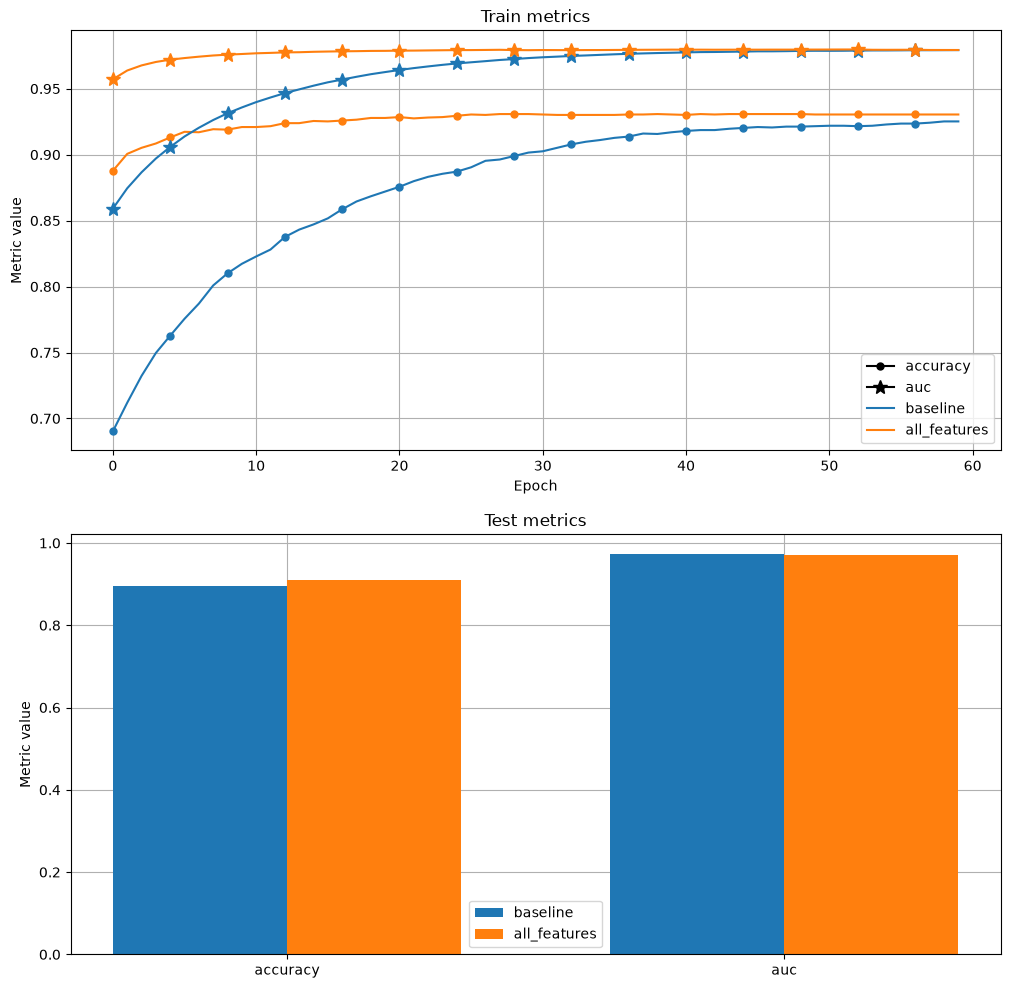

In [23]:
# Comparing our two models
ml_edu.results.compare_experiment([experiment, experiment_all_feature],
                                  ['accuracy', 'auc'],
                                  validation_features, validation_labels)

In [25]:
# Computing the final test metrics
test_metrics_all_features = experiment_all_feature.evaluate(
    test_features,
    test_labels
)
for metric, test_value in test_metrics_all_features.items():
    print(f'Test {metric}: {test_value:.4f}')

Test accuracy: 0.9213
Test auc: 0.9761
Test loss: 0.1900
Test precision: 0.9067
Test recall: 0.8947
